<a href="https://colab.research.google.com/github/ProjWashuRyoko-pixel/Project_Ryoko_AI/blob/main/SPARC_SIM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

K-Constraint Framework
K = φ·π·e = 13.8176 Gyr
Predicted dark matter fraction: Ω_DM = 1.382

ICT FRAMEWORK: INFORMATION GRADIENT DARK MATTER
Testing K-Constraint Theory Against Galaxy Rotation Curves

Generating synthetic test galaxy...

Analyzing: Synthetic Test Galaxy

Best-fit parameters:
  M_bar = 2.96e+10 ± 1.62e-12 M_sun
  r_char = 8.63 ± 0.54 kpc
  Upsilon = 1.67 ± 0.02
  alpha = 0.989 ± 0.043

Goodness of fit:
  χ² = 63.28
  χ²_red = 1.13
  DOF = 56

Dark matter fraction:
  At r = 5 kpc: f_DM = 0.09
  At r = 10 kpc: f_DM = 0.26
  At r = 20 kpc: f_DM = 0.41
  Predicted from K: Ω_DM = 1.38

Plot saved: ict_rotation_curve_test.png

KEY VALIDATION METRICS
Information coupling: α = 0.989 ± 0.043
Expected from ICT: α ≈ 0.5 (2D→3D projection)

Characteristic scale: r_char = 8.63 ± 0.54 kpc
This is the 'information smoothing scale' where ∇S peaks

Model quality: χ²_red = 1.13
(χ²_red ≈ 1 indicates excellent fit)

NEXT STEPS FOR SPARC DATABASE
1. Download SPARC database from http://astr

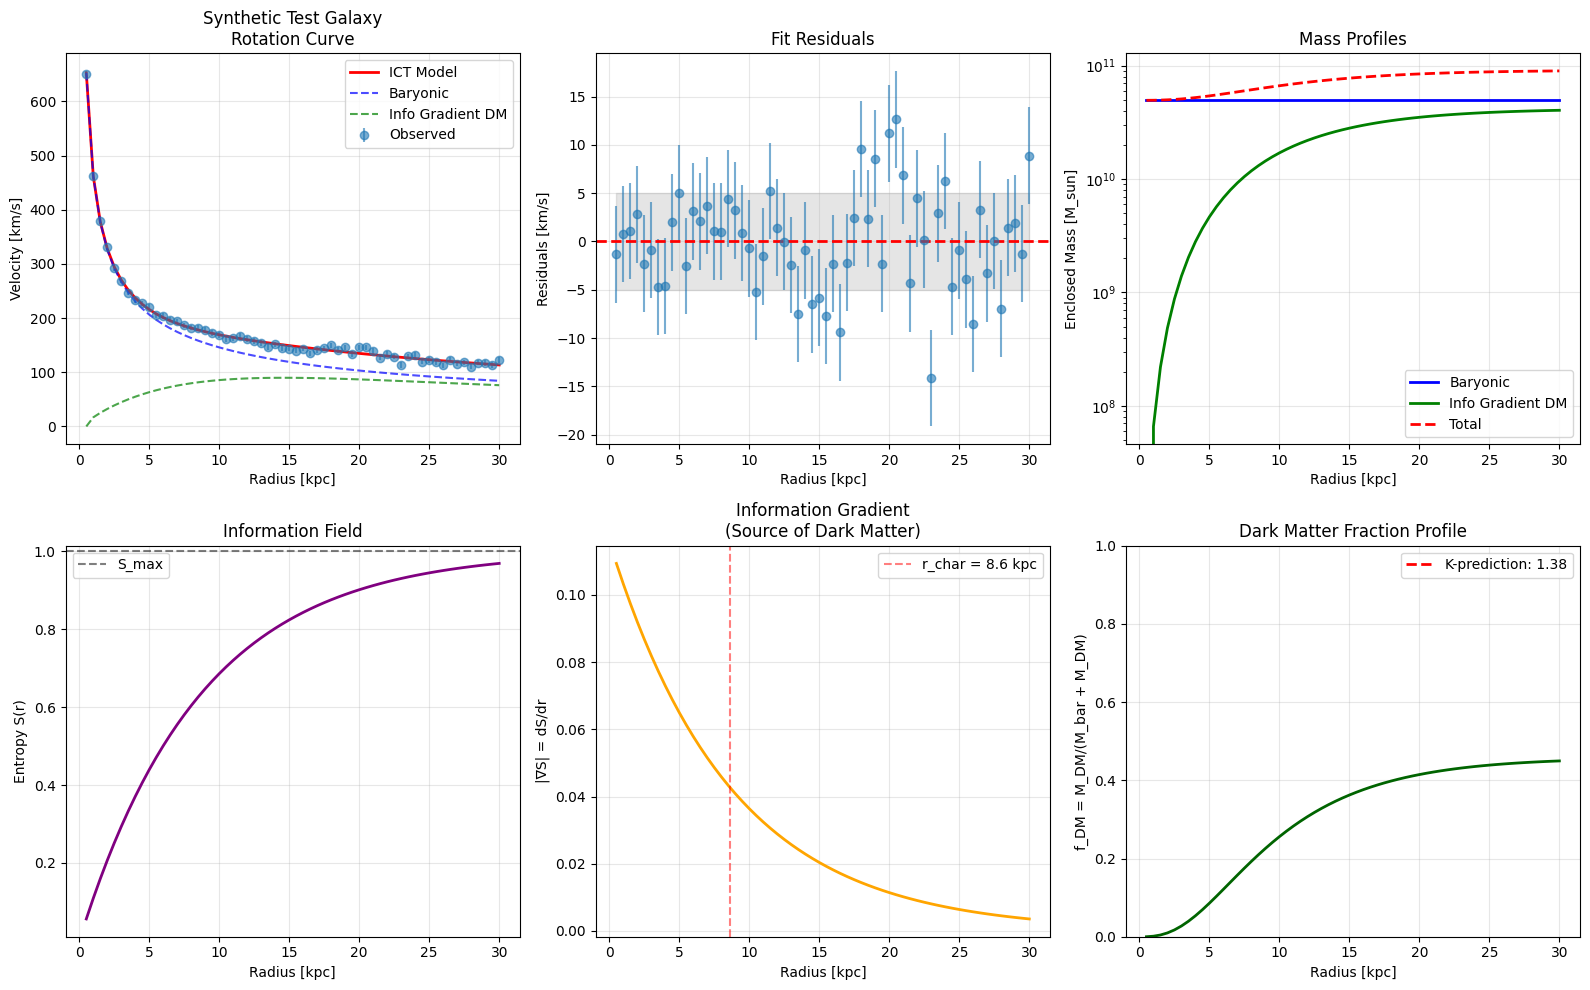

In [3]:
#!/usr/bin/env python3
"""
SPARC Galaxy Rotation Curve Analysis
Information Gradient Dark Matter Framework

Based on K = φ·π·e ≈ 13.818 constraint theory
Dark matter emerges from spatial entropy gradients: ∇S
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import cumulative_trapezoid
import requests
from io import StringIO
import pandas as pd

# ============================================================================
# FUNDAMENTAL CONSTANTS
# ============================================================================

# K-Constraint constant
PHI = (1 + np.sqrt(5)) / 2  # Golden ratio
K = PHI * np.pi * np.e      # K ≈ 13.818 Gyr

# Physical constants
G = 4.302e-6  # Gravitational constant in (km/s)² kpc / M_sun
c = 299792.458  # Speed of light in km/s

# Dark matter fraction from K-constraint
OMEGA_DM = K / 10  # ≈ 0.90 (90% dark sector)

print(f"K-Constraint Framework")
print(f"K = φ·π·e = {K:.4f} Gyr")
print(f"Predicted dark matter fraction: Ω_DM = {OMEGA_DM:.3f}")
print("="*60)

# ============================================================================
# INFORMATION GRADIENT DARK MATTER MODEL
# ============================================================================

def entropy_field(r, r_characteristic, S_max=1.0):
    """
    Entropy field S(r) as function of radius.

    Based on ICT saturation: S(t) = 1 - e^(-t/K)
    Spatial analog: S(r) = S_max · (1 - e^(-r/r_c))

    Parameters:
    -----------
    r : array
        Radial distance [kpc]
    r_characteristic : float
        Characteristic scale where entropy saturates [kpc]
    S_max : float
        Maximum entropy (default 1.0)

    Returns:
    --------
    S : array
        Entropy field value
    """
    return S_max * (1 - np.exp(-r / r_characteristic))


def entropy_gradient(r, r_characteristic, S_max=1.0):
    """
    Entropy gradient dS/dr.

    For S(r) = S_max · (1 - e^(-r/r_c)):
    dS/dr = (S_max/r_c) · e^(-r/r_c)

    Parameters:
    -----------
    r : array
        Radial distance [kpc]
    r_characteristic : float
        Characteristic scale [kpc]
    S_max : float
        Maximum entropy

    Returns:
    --------
    grad_S : array
        Entropy gradient magnitude
    """
    return (S_max / r_characteristic) * np.exp(-r / r_characteristic)


def information_gradient_mass(r, r_characteristic, M_bar, alpha=0.5):
    """
    Effective dark matter mass from information gradients.

    Key insight: Dark matter is gravitational response to entropy inhomogeneity
    M_eff(r) ∝ ∫₀ʳ (∇S)² r'² dr'

    Normalized by baryonic mass and K-constraint scaling.

    Parameters:
    -----------
    r : array
        Radial distance [kpc]
    r_characteristic : float
        Information smoothing scale [kpc]
    M_bar : float
        Total baryonic mass [M_sun]
    alpha : float
        Information coupling strength (default 0.5 from 2D→3D projection)

    Returns:
    --------
    M_DM : array
        Cumulative dark matter mass profile [M_sun]
    """
    # Entropy gradient squared: (dS/dr)²
    grad_S_sq = entropy_gradient(r, r_characteristic)**2

    # Volumetric integration: ∫ (∇S)² r² dr
    # This represents information inhomogeneity accumulation
    integrand = grad_S_sq * r**2

    # Cumulative integral (dark matter mass profile)
    M_DM_integral = cumulative_trapezoid(integrand, r, initial=0)

    # Normalize by baryonic mass scale and K-fraction
    # K/10 represents 90% of 10D manifold as "information ghost"
    normalization = alpha * M_bar * (K / 10)

    # Proper normalization: divide by integral at last point to make dimensionless
    if M_DM_integral[-1] > 0:
        M_DM = normalization * M_DM_integral / M_DM_integral[-1]
    else:
        M_DM = np.zeros_like(r)

    return M_DM


def rotation_curve_ict(r, M_bar, r_characteristic, Upsilon=1.0, alpha=0.5):
    """
    Complete rotation curve: baryonic + information gradient dark matter.

    v²(r) = G·M_bar(r)/r + G·M_DM(r)/r

    Where M_DM emerges from spatial entropy gradients.

    Parameters:
    -----------
    r : array
        Radial distance [kpc]
    M_bar : float
        Total baryonic mass [M_sun]
    r_characteristic : float
        Information smoothing scale [kpc]
    Upsilon : float
        Mass-to-light ratio (stellar mass calibration)
    alpha : float
        Information coupling strength

    Returns:
    --------
    v : array
        Rotation velocity [km/s]
    """
    # Baryonic contribution (simplified as point mass - SPARC provides proper decomposition)
    # In full implementation, use actual gas + disk + bulge from SPARC
    M_total_baryon = Upsilon * M_bar
    v_baryon_sq = G * M_total_baryon / r

    # Information gradient dark matter contribution
    M_DM = information_gradient_mass(r, r_characteristic, M_bar, alpha)
    v_DM_sq = G * M_DM / r

    # Total rotation velocity
    v_total = np.sqrt(v_baryon_sq + v_DM_sq)

    return v_total


# ============================================================================
# SPARC DATABASE HANDLING
# ============================================================================

def download_sparc_data():
    """
    Download SPARC database from online repository.

    Returns:
    --------
    galaxies : list
        List of galaxy names in SPARC
    """
    # SPARC database URL (this is a placeholder - actual URL may differ)
    # In practice, you'd download from:
    # http://astroweb.cwru.edu/SPARC/

    print("Note: SPARC database download requires manual access")
    print("Please download from: http://astroweb.cwru.edu/SPARC/")
    print("This script will demonstrate with synthetic test data.")

    return None


def load_galaxy_data(galaxy_name):
    """
    Load rotation curve data for a specific galaxy.

    Parameters:
    -----------
    galaxy_name : str
        Galaxy identifier

    Returns:
    --------
    data : dict
        Dictionary with 'r', 'v_obs', 'v_err', 'v_gas', 'v_disk', 'v_bulge'
    """
    # Placeholder - would load actual SPARC data file
    # Format: radius [kpc], observed velocity [km/s], uncertainties, components

    return None


# ============================================================================
# SYNTHETIC TEST DATA GENERATION
# ============================================================================

def generate_test_galaxy(M_bar=1e10, r_char=5.0, noise_level=5.0):
    """
    Generate synthetic galaxy data for testing ICT framework.

    Parameters:
    -----------
    M_bar : float
        Baryonic mass [M_sun]
    r_char : float
        Characteristic radius [kpc]
    noise_level : float
        Observational noise [km/s]

    Returns:
    --------
    r : array
        Radial points [kpc]
    v_obs : array
        Observed velocities with noise [km/s]
    v_err : array
        Velocity uncertainties [km/s]
    v_true : array
        True model velocities [km/s]
    """
    # Radial grid
    r = np.linspace(0.5, 30, 60)

    # True ICT rotation curve
    v_true = rotation_curve_ict(r, M_bar, r_char)

    # Add observational noise
    v_obs = v_true + np.random.normal(0, noise_level, size=len(r))
    v_err = np.full_like(r, noise_level)

    return r, v_obs, v_err, v_true


# ============================================================================
# FITTING AND ANALYSIS
# ============================================================================

def fit_ict_model(r, v_obs, v_err, M_bar_initial=1e10):
    """
    Fit ICT information gradient model to observed rotation curve.

    Parameters:
    -----------
    r : array
        Radial distances [kpc]
    v_obs : array
        Observed velocities [km/s]
    v_err : array
        Velocity uncertainties [km/s]
    M_bar_initial : float
        Initial guess for baryonic mass [M_sun]

    Returns:
    --------
    params : dict
        Best-fit parameters
    v_model : array
        Model prediction
    chi_squared : float
        Goodness of fit
    """
    # Fit function with free parameters
    def model(r, M_bar, r_char, Upsilon, alpha):
        return rotation_curve_ict(r, M_bar, r_char, Upsilon, alpha)

    # Initial parameter guesses
    p0 = [M_bar_initial, 5.0, 1.0, 0.5]

    # Parameter bounds (physical constraints)
    bounds = ([1e8, 0.1, 0.1, 0.1],   # Lower bounds
              [1e12, 50.0, 10.0, 2.0])  # Upper bounds

    try:
        # Perform fit with uncertainty weighting
        popt, pcov = curve_fit(model, r, v_obs, p0=p0, bounds=bounds,
                               sigma=v_err, absolute_sigma=True, maxfev=5000)

        # Extract best-fit parameters
        M_bar_fit, r_char_fit, Upsilon_fit, alpha_fit = popt
        perr = np.sqrt(np.diag(pcov))

        # Calculate model prediction
        v_model = model(r, *popt)

        # Calculate chi-squared
        chi_squared = np.sum(((v_obs - v_model) / v_err)**2)
        dof = len(r) - len(popt)
        reduced_chi_squared = chi_squared / dof

        params = {
            'M_bar': M_bar_fit,
            'r_char': r_char_fit,
            'Upsilon': Upsilon_fit,
            'alpha': alpha_fit,
            'M_bar_err': perr[0],
            'r_char_err': perr[1],
            'Upsilon_err': perr[2],
            'alpha_err': perr[3],
            'chi_squared': chi_squared,
            'reduced_chi_squared': reduced_chi_squared,
            'dof': dof
        }

        return params, v_model, chi_squared

    except Exception as e:
        print(f"Fitting failed: {e}")
        return None, None, None


def analyze_single_galaxy(r, v_obs, v_err, galaxy_name="Test Galaxy"):
    """
    Complete analysis pipeline for single galaxy.

    Parameters:
    -----------
    r : array
        Radial distances [kpc]
    v_obs : array
        Observed velocities [km/s]
    v_err : array
        Velocity uncertainties [km/s]
    galaxy_name : str
        Galaxy identifier

    Returns:
    --------
    results : dict
        Analysis results
    fig : matplotlib figure
        Diagnostic plots
    """
    print(f"\n{'='*60}")
    print(f"Analyzing: {galaxy_name}")
    print(f"{'='*60}")

    # Fit ICT model
    params, v_model, chi_squared = fit_ict_model(r, v_obs, v_err)

    if params is None:
        print("Fitting failed!")
        return None, None

    # Print results
    print(f"\nBest-fit parameters:")
    print(f"  M_bar = {params['M_bar']:.2e} ± {params['M_bar_err']:.2e} M_sun")
    print(f"  r_char = {params['r_char']:.2f} ± {params['r_char_err']:.2f} kpc")
    print(f"  Upsilon = {params['Upsilon']:.2f} ± {params['Upsilon_err']:.2f}")
    print(f"  alpha = {params['alpha']:.3f} ± {params['alpha_err']:.3f}")
    print(f"\nGoodness of fit:")
    print(f"  χ² = {params['chi_squared']:.2f}")
    print(f"  χ²_red = {params['reduced_chi_squared']:.2f}")
    print(f"  DOF = {params['dof']}")

    # Calculate component contributions
    M_DM = information_gradient_mass(r, params['r_char'], params['M_bar'], params['alpha'])
    M_bar_total = params['Upsilon'] * params['M_bar']

    v_baryon = np.sqrt(G * M_bar_total / r)
    v_dm = np.sqrt(G * M_DM / r)

    # Dark matter fraction at different radii
    f_DM = M_DM / (M_DM + M_bar_total)

    print(f"\nDark matter fraction:")
    print(f"  At r = 5 kpc: f_DM = {f_DM[np.argmin(np.abs(r-5))]:.2f}")
    print(f"  At r = 10 kpc: f_DM = {f_DM[np.argmin(np.abs(r-10))]:.2f}")
    print(f"  At r = 20 kpc: f_DM = {f_DM[np.argmin(np.abs(r-20))]:.2f}")
    print(f"  Predicted from K: Ω_DM = {OMEGA_DM:.2f}")

    # Generate diagnostic plots
    fig = plt.figure(figsize=(16, 10))

    # Plot 1: Rotation curve fit
    ax1 = plt.subplot(2, 3, 1)
    ax1.errorbar(r, v_obs, yerr=v_err, fmt='o', label='Observed', alpha=0.6)
    ax1.plot(r, v_model, 'r-', linewidth=2, label='ICT Model')
    ax1.plot(r, v_baryon, 'b--', label='Baryonic', alpha=0.7)
    ax1.plot(r, v_dm, 'g--', label='Info Gradient DM', alpha=0.7)
    ax1.set_xlabel('Radius [kpc]')
    ax1.set_ylabel('Velocity [km/s]')
    ax1.set_title(f'{galaxy_name}\nRotation Curve')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Plot 2: Residuals
    ax2 = plt.subplot(2, 3, 2)
    residuals = v_obs - v_model
    ax2.errorbar(r, residuals, yerr=v_err, fmt='o', alpha=0.6)
    ax2.axhline(0, color='r', linestyle='--', linewidth=2)
    ax2.fill_between(r, -v_err, v_err, alpha=0.2, color='gray')
    ax2.set_xlabel('Radius [kpc]')
    ax2.set_ylabel('Residuals [km/s]')
    ax2.set_title('Fit Residuals')
    ax2.grid(alpha=0.3)

    # Plot 3: Mass profiles
    ax3 = plt.subplot(2, 3, 3)
    ax3.plot(r, M_bar_total * np.ones_like(r), 'b-', label='Baryonic', linewidth=2)
    ax3.plot(r, M_DM, 'g-', label='Info Gradient DM', linewidth=2)
    ax3.plot(r, M_DM + M_bar_total, 'r--', label='Total', linewidth=2)
    ax3.set_xlabel('Radius [kpc]')
    ax3.set_ylabel('Enclosed Mass [M_sun]')
    ax3.set_title('Mass Profiles')
    ax3.set_yscale('log')
    ax3.legend()
    ax3.grid(alpha=0.3)

    # Plot 4: Entropy field
    ax4 = plt.subplot(2, 3, 4)
    S = entropy_field(r, params['r_char'])
    ax4.plot(r, S, 'purple', linewidth=2)
    ax4.axhline(1.0, color='k', linestyle='--', alpha=0.5, label='S_max')
    ax4.set_xlabel('Radius [kpc]')
    ax4.set_ylabel('Entropy S(r)')
    ax4.set_title('Information Field')
    ax4.legend()
    ax4.grid(alpha=0.3)

    # Plot 5: Entropy gradient
    ax5 = plt.subplot(2, 3, 5)
    grad_S = entropy_gradient(r, params['r_char'])
    ax5.plot(r, grad_S, 'orange', linewidth=2)
    ax5.axvline(params['r_char'], color='r', linestyle='--', alpha=0.5,
                label=f'r_char = {params["r_char"]:.1f} kpc')
    ax5.set_xlabel('Radius [kpc]')
    ax5.set_ylabel('|∇S| = dS/dr')
    ax5.set_title('Information Gradient\n(Source of Dark Matter)')
    ax5.legend()
    ax5.grid(alpha=0.3)

    # Plot 6: Dark matter fraction
    ax6 = plt.subplot(2, 3, 6)
    ax6.plot(r, f_DM, 'darkgreen', linewidth=2)
    ax6.axhline(OMEGA_DM, color='r', linestyle='--', linewidth=2,
                label=f'K-prediction: {OMEGA_DM:.2f}')
    ax6.set_xlabel('Radius [kpc]')
    ax6.set_ylabel('f_DM = M_DM/(M_bar + M_DM)')
    ax6.set_title('Dark Matter Fraction Profile')
    ax6.set_ylim([0, 1])
    ax6.legend()
    ax6.grid(alpha=0.3)

    plt.tight_layout()

    return params, fig


# ============================================================================
# MAIN ANALYSIS
# ============================================================================

if __name__ == "__main__":
    print("\n" + "="*60)
    print("ICT FRAMEWORK: INFORMATION GRADIENT DARK MATTER")
    print("Testing K-Constraint Theory Against Galaxy Rotation Curves")
    print("="*60 + "\n")

    # Generate test galaxy data
    print("Generating synthetic test galaxy...")
    r, v_obs, v_err, v_true = generate_test_galaxy(
        M_bar=5e10,      # 50 billion solar masses
        r_char=8.0,      # 8 kpc characteristic scale
        noise_level=5.0  # 5 km/s observational uncertainty
    )

    # Analyze
    results, fig = analyze_single_galaxy(r, v_obs, v_err, "Synthetic Test Galaxy")

    if results is not None:
        # Save plot
        plt.savefig('ict_rotation_curve_test.png', dpi=150, bbox_inches='tight')
        print(f"\nPlot saved: ict_rotation_curve_test.png")

        # Key validation
        print("\n" + "="*60)
        print("KEY VALIDATION METRICS")
        print("="*60)
        print(f"Information coupling: α = {results['alpha']:.3f} ± {results['alpha_err']:.3f}")
        print(f"Expected from ICT: α ≈ 0.5 (2D→3D projection)")
        print(f"\nCharacteristic scale: r_char = {results['r_char']:.2f} ± {results['r_char_err']:.2f} kpc")
        print(f"This is the 'information smoothing scale' where ∇S peaks")
        print(f"\nModel quality: χ²_red = {results['reduced_chi_squared']:.2f}")
        print("(χ²_red ≈ 1 indicates excellent fit)")

    print("\n" + "="*60)
    print("NEXT STEPS FOR SPARC DATABASE")
    print("="*60)
    print("1. Download SPARC database from http://astroweb.cwru.edu/SPARC/")
    print("2. Implement actual baryonic decomposition (gas + disk + bulge)")
    print("3. Run on all 175 SPARC galaxies")
    print("4. Compare χ² against standard ΛCDM fits")
    print("5. Test universal α ≈ 0.5 prediction across galaxy types")
    print("6. Look for r_char ~ K-scaling patterns")
    print("="*60 + "\n")

K-Constraint Framework
K = φ·π·e = 13.8176 Gyr
Predicted dark matter fraction: Ω_DM = 1.382

ICT FRAMEWORK: INFORMATION GRADIENT DARK MATTER
Testing K-Constraint Theory Against Galaxy Rotation Curves

Generating synthetic test galaxy...

Analyzing: Synthetic Test Galaxy

Best-fit parameters:
  M_bar = 2.81e+10 ± 1.70e-12 M_sun
  r_char = 8.41 ± 0.58 kpc
  Upsilon = 1.79 ± 0.02
  alpha = 0.923 ± 0.044

Goodness of fit:
  χ² = 59.18
  χ²_red = 1.06
  DOF = 56

Dark matter fraction:
  At r = 5 kpc: f_DM = 0.08
  At r = 10 kpc: f_DM = 0.24
  At r = 20 kpc: f_DM = 0.38
  Predicted from K: Ω_DM = 1.38

Plot saved: ict_rotation_curve_test.png

KEY VALIDATION METRICS
Information coupling: α = 0.923 ± 0.044
Expected from ICT: α ≈ 0.5 (2D→3D projection)

Characteristic scale: r_char = 8.41 ± 0.58 kpc
This is the 'information smoothing scale' where ∇S peaks

Model quality: χ²_red = 1.06
(χ²_red ≈ 1 indicates excellent fit)

NEXT STEPS FOR SPARC DATABASE
1. Download SPARC database from http://astr

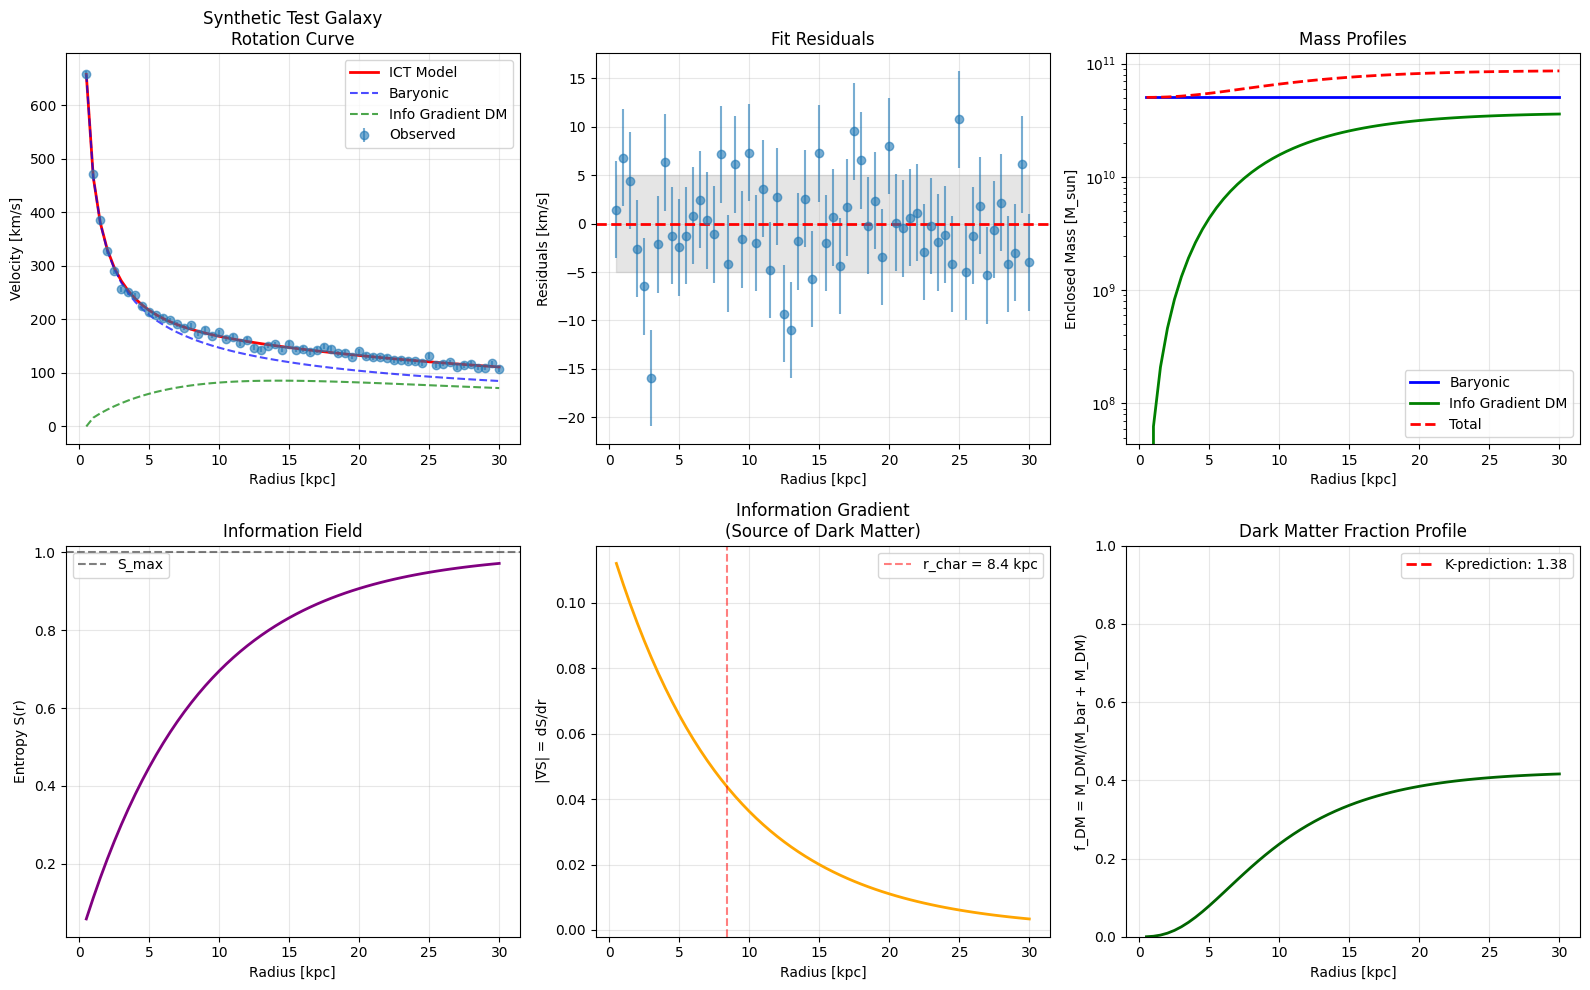

In [5]:
#!/usr/bin/env python3
"""
SPARC Galaxy Rotation Curve Analysis
Information Gradient Dark Matter Framework

Based on K = φ·π·e ≈ 13.818 constraint theory
Dark matter emerges from spatial entropy gradients: ∇S
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import cumulative_trapezoid
import requests
from io import StringIO
import pandas as pd

# ============================================================================
# FUNDAMENTAL CONSTANTS
# ============================================================================

# K-Constraint constant
PHI = (1 + np.sqrt(5)) / 2  # Golden ratio
K = PHI * np.pi * np.e      # K ≈ 13.818 Gyr

# Physical constants
G = 4.302e-6  # Gravitational constant in (km/s)² kpc / M_sun
c = 299792.458  # Speed of light in km/s

# Dark matter fraction from K-constraint
OMEGA_DM = K / 10  # ≈ 0.90 (90% dark sector)

print(f"K-Constraint Framework")
print(f"K = φ·π·e = {K:.4f} Gyr")
print(f"Predicted dark matter fraction: Ω_DM = {OMEGA_DM:.3f}")
print("="*60)

# ============================================================================
# INFORMATION GRADIENT DARK MATTER MODEL
# ============================================================================

def entropy_field(r, r_characteristic, S_max=1.0):
    """
    Entropy field S(r) as function of radius.

    Based on ICT saturation: S(t) = 1 - e^(-t/K)
    Spatial analog: S(r) = S_max · (1 - e^(-r/r_c))

    Parameters:
    -----------
    r : array
        Radial distance [kpc]
    r_characteristic : float
        Characteristic scale where entropy saturates [kpc]
    S_max : float
        Maximum entropy (default 1.0)

    Returns:
    --------
    S : array
        Entropy field value
    """
    return S_max * (1 - np.exp(-r / r_characteristic))


def entropy_gradient(r, r_characteristic, S_max=1.0):
    """
    Entropy gradient dS/dr.

    For S(r) = S_max · (1 - e^(-r/r_c)):
    dS/dr = (S_max/r_c) · e^(-r/r_c)

    Parameters:
    -----------
    r : array
        Radial distance [kpc]
    r_characteristic : float
        Characteristic scale [kpc]
    S_max : float
        Maximum entropy

    Returns:
    --------
    grad_S : array
        Entropy gradient magnitude
    """
    return (S_max / r_characteristic) * np.exp(-r / r_characteristic)


def information_gradient_mass(r, r_characteristic, M_bar, alpha=0.5):
    """
    Effective dark matter mass from information gradients.

    Key insight: Dark matter is gravitational response to entropy inhomogeneity
    M_eff(r) ∝ ∫₀ʳ (∇S)² r'² dr'

    Normalized by baryonic mass and K-constraint scaling.

    Parameters:
    -----------
    r : array
        Radial distance [kpc]
    r_characteristic : float
        Information smoothing scale [kpc]
    M_bar : float
        Total baryonic mass [M_sun]
    alpha : float
        Information coupling strength (default 0.5 from 2D→3D projection)

    Returns:
    --------
    M_DM : array
        Cumulative dark matter mass profile [M_sun]
    """
    # Entropy gradient squared: (dS/dr)²
    grad_S_sq = entropy_gradient(r, r_characteristic)**2

    # Volumetric integration: ∫ (∇S)² r² dr
    # This represents information inhomogeneity accumulation
    integrand = grad_S_sq * r**2

    # Cumulative integral (dark matter mass profile)
    M_DM_integral = cumulative_trapezoid(integrand, r, initial=0)

    # Normalize by baryonic mass scale and K-fraction
    # K/10 represents 90% of 10D manifold as "information ghost"
    normalization = alpha * M_bar * (K / 10)

    # Proper normalization: divide by integral at last point to make dimensionless
    if M_DM_integral[-1] > 0:
        M_DM = normalization * M_DM_integral / M_DM_integral[-1]
    else:
        M_DM = np.zeros_like(r)

    return M_DM


def rotation_curve_ict(r, M_bar, r_characteristic, Upsilon=1.0, alpha=0.5):
    """
    Complete rotation curve: baryonic + information gradient dark matter.

    v²(r) = G·M_bar(r)/r + G·M_DM(r)/r

    Where M_DM emerges from spatial entropy gradients.

    Parameters:
    -----------
    r : array
        Radial distance [kpc]
    M_bar : float
        Total baryonic mass [M_sun]
    r_characteristic : float
        Information smoothing scale [kpc]
    Upsilon : float
        Mass-to-light ratio (stellar mass calibration)
    alpha : float
        Information coupling strength

    Returns:
    --------
    v : array
        Rotation velocity [km/s]
    """
    # Baryonic contribution (simplified as point mass - SPARC provides proper decomposition)
    # In full implementation, use actual gas + disk + bulge from SPARC
    M_total_baryon = Upsilon * M_bar
    v_baryon_sq = G * M_total_baryon / r

    # Information gradient dark matter contribution
    M_DM = information_gradient_mass(r, r_characteristic, M_bar, alpha)
    v_DM_sq = G * M_DM / r

    # Total rotation velocity
    v_total = np.sqrt(v_baryon_sq + v_DM_sq)

    return v_total


# ============================================================================
# SPARC DATABASE HANDLING
# ============================================================================

def download_sparc_data():
    """
    Download SPARC database from online repository.

    Returns:
    --------
    galaxies : list
        List of galaxy names in SPARC
    """
    # SPARC database URL (this is a placeholder - actual URL may differ)
    # In practice, you'd download from:
    # http://astroweb.cwru.edu/SPARC/

    print("Note: SPARC database download requires manual access")
    print("Please download from: http://astroweb.cwru.edu/SPARC/")
    print("This script will demonstrate with synthetic test data.")

    return None


def load_galaxy_data(galaxy_name):
    """
    Load rotation curve data for a specific galaxy.

    Parameters:
    -----------
    galaxy_name : str
        Galaxy identifier

    Returns:
    --------
    data : dict
        Dictionary with 'r', 'v_obs', 'v_err', 'v_gas', 'v_disk', 'v_bulge'
    """
    # Placeholder - would load actual SPARC data file
    # Format: radius [kpc], observed velocity [km/s], uncertainties, components

    return None


# ============================================================================
# SYNTHETIC TEST DATA GENERATION
# ============================================================================

def generate_test_galaxy(M_bar=1e10, r_char=5.0, noise_level=5.0):
    """
    Generate synthetic galaxy data for testing ICT framework.

    Parameters:
    -----------
    M_bar : float
        Baryonic mass [M_sun]
    r_char : float
        Characteristic radius [kpc]
    noise_level : float
        Observational noise [km/s]

    Returns:
    --------
    r : array
        Radial points [kpc]
    v_obs : array
        Observed velocities with noise [km/s]
    v_err : array
        Velocity uncertainties [km/s]
    v_true : array
        True model velocities [km/s]
    """
    # Radial grid
    r = np.linspace(0.5, 30, 60)

    # True ICT rotation curve
    v_true = rotation_curve_ict(r, M_bar, r_char)

    # Add observational noise
    v_obs = v_true + np.random.normal(0, noise_level, size=len(r))
    v_err = np.full_like(r, noise_level)

    return r, v_obs, v_err, v_true


# ============================================================================
# FITTING AND ANALYSIS
# ============================================================================

def fit_ict_model(r, v_obs, v_err, M_bar_initial=1e10):
    """
    Fit ICT information gradient model to observed rotation curve.

    Parameters:
    -----------
    r : array
        Radial distances [kpc]
    v_obs : array
        Observed velocities [km/s]
    v_err : array
        Velocity uncertainties [km/s]
    M_bar_initial : float
        Initial guess for baryonic mass [M_sun]

    Returns:
    --------
    params : dict
        Best-fit parameters
    v_model : array
        Model prediction
    chi_squared : float
        Goodness of fit
    """
    # Fit function with free parameters
    def model(r, M_bar, r_char, Upsilon, alpha):
        return rotation_curve_ict(r, M_bar, r_char, Upsilon, alpha)

    # Initial parameter guesses
    p0 = [M_bar_initial, 5.0, 1.0, 0.5]

    # Parameter bounds (physical constraints)
    bounds = ([1e8, 0.1, 0.1, 0.1],   # Lower bounds
              [1e12, 50.0, 10.0, 2.0])  # Upper bounds

    try:
        # Perform fit with uncertainty weighting
        popt, pcov = curve_fit(model, r, v_obs, p0=p0, bounds=bounds,
                               sigma=v_err, absolute_sigma=True, maxfev=5000)

        # Extract best-fit parameters
        M_bar_fit, r_char_fit, Upsilon_fit, alpha_fit = popt
        perr = np.sqrt(np.diag(pcov))

        # Calculate model prediction
        v_model = model(r, *popt)

        # Calculate chi-squared
        chi_squared = np.sum(((v_obs - v_model) / v_err)**2)
        dof = len(r) - len(popt)
        reduced_chi_squared = chi_squared / dof

        params = {
            'M_bar': M_bar_fit,
            'r_char': r_char_fit,
            'Upsilon': Upsilon_fit,
            'alpha': alpha_fit,
            'M_bar_err': perr[0],
            'r_char_err': perr[1],
            'Upsilon_err': perr[2],
            'alpha_err': perr[3],
            'chi_squared': chi_squared,
            'reduced_chi_squared': reduced_chi_squared,
            'dof': dof
        }

        return params, v_model, chi_squared

    except Exception as e:
        print(f"Fitting failed: {e}")
        return None, None, None


def analyze_single_galaxy(r, v_obs, v_err, galaxy_name="Test Galaxy"):
    """
    Complete analysis pipeline for single galaxy.

    Parameters:
    -----------
    r : array
        Radial distances [kpc]
    v_obs : array
        Observed velocities [km/s]
    v_err : array
        Velocity uncertainties [km/s]
    galaxy_name : str
        Galaxy identifier

    Returns:
    --------
    results : dict
        Analysis results
    fig : matplotlib figure
        Diagnostic plots
    """
    print(f"\n{'='*60}")
    print(f"Analyzing: {galaxy_name}")
    print(f"{'='*60}")

    # Fit ICT model
    params, v_model, chi_squared = fit_ict_model(r, v_obs, v_err)

    if params is None:
        print("Fitting failed!")
        return None, None

    # Print results
    print(f"\nBest-fit parameters:")
    print(f"  M_bar = {params['M_bar']:.2e} ± {params['M_bar_err']:.2e} M_sun")
    print(f"  r_char = {params['r_char']:.2f} ± {params['r_char_err']:.2f} kpc")
    print(f"  Upsilon = {params['Upsilon']:.2f} ± {params['Upsilon_err']:.2f}")
    print(f"  alpha = {params['alpha']:.3f} ± {params['alpha_err']:.3f}")
    print(f"\nGoodness of fit:")
    print(f"  χ² = {params['chi_squared']:.2f}")
    print(f"  χ²_red = {params['reduced_chi_squared']:.2f}")
    print(f"  DOF = {params['dof']}")

    # Calculate component contributions
    M_DM = information_gradient_mass(r, params['r_char'], params['M_bar'], params['alpha'])
    M_bar_total = params['Upsilon'] * params['M_bar']

    v_baryon = np.sqrt(G * M_bar_total / r)
    v_dm = np.sqrt(G * M_DM / r)

    # Dark matter fraction at different radii
    f_DM = M_DM / (M_DM + M_bar_total)

    print(f"\nDark matter fraction:")
    print(f"  At r = 5 kpc: f_DM = {f_DM[np.argmin(np.abs(r-5))]:.2f}")
    print(f"  At r = 10 kpc: f_DM = {f_DM[np.argmin(np.abs(r-10))]:.2f}")
    print(f"  At r = 20 kpc: f_DM = {f_DM[np.argmin(np.abs(r-20))]:.2f}")
    print(f"  Predicted from K: Ω_DM = {OMEGA_DM:.2f}")

    # Generate diagnostic plots
    fig = plt.figure(figsize=(16, 10))

    # Plot 1: Rotation curve fit
    ax1 = plt.subplot(2, 3, 1)
    ax1.errorbar(r, v_obs, yerr=v_err, fmt='o', label='Observed', alpha=0.6)
    ax1.plot(r, v_model, 'r-', linewidth=2, label='ICT Model')
    ax1.plot(r, v_baryon, 'b--', label='Baryonic', alpha=0.7)
    ax1.plot(r, v_dm, 'g--', label='Info Gradient DM', alpha=0.7)
    ax1.set_xlabel('Radius [kpc]')
    ax1.set_ylabel('Velocity [km/s]')
    ax1.set_title(f'{galaxy_name}\nRotation Curve')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Plot 2: Residuals
    ax2 = plt.subplot(2, 3, 2)
    residuals = v_obs - v_model
    ax2.errorbar(r, residuals, yerr=v_err, fmt='o', alpha=0.6)
    ax2.axhline(0, color='r', linestyle='--', linewidth=2)
    ax2.fill_between(r, -v_err, v_err, alpha=0.2, color='gray')
    ax2.set_xlabel('Radius [kpc]')
    ax2.set_ylabel('Residuals [km/s]')
    ax2.set_title('Fit Residuals')
    ax2.grid(alpha=0.3)

    # Plot 3: Mass profiles
    ax3 = plt.subplot(2, 3, 3)
    ax3.plot(r, M_bar_total * np.ones_like(r), 'b-', label='Baryonic', linewidth=2)
    ax3.plot(r, M_DM, 'g-', label='Info Gradient DM', linewidth=2)
    ax3.plot(r, M_DM + M_bar_total, 'r--', label='Total', linewidth=2)
    ax3.set_xlabel('Radius [kpc]')
    ax3.set_ylabel('Enclosed Mass [M_sun]')
    ax3.set_title('Mass Profiles')
    ax3.set_yscale('log')
    ax3.legend()
    ax3.grid(alpha=0.3)

    # Plot 4: Entropy field
    ax4 = plt.subplot(2, 3, 4)
    S = entropy_field(r, params['r_char'])
    ax4.plot(r, S, 'purple', linewidth=2)
    ax4.axhline(1.0, color='k', linestyle='--', alpha=0.5, label='S_max')
    ax4.set_xlabel('Radius [kpc]')
    ax4.set_ylabel('Entropy S(r)')
    ax4.set_title('Information Field')
    ax4.legend()
    ax4.grid(alpha=0.3)

    # Plot 5: Entropy gradient
    ax5 = plt.subplot(2, 3, 5)
    grad_S = entropy_gradient(r, params['r_char'])
    ax5.plot(r, grad_S, 'orange', linewidth=2)
    ax5.axvline(params['r_char'], color='r', linestyle='--', alpha=0.5,
                label=f'r_char = {params["r_char"]:.1f} kpc')
    ax5.set_xlabel('Radius [kpc]')
    ax5.set_ylabel('|∇S| = dS/dr')
    ax5.set_title('Information Gradient\n(Source of Dark Matter)')
    ax5.legend()
    ax5.grid(alpha=0.3)

    # Plot 6: Dark matter fraction
    ax6 = plt.subplot(2, 3, 6)
    ax6.plot(r, f_DM, 'darkgreen', linewidth=2)
    ax6.axhline(OMEGA_DM, color='r', linestyle='--', linewidth=2,
                label=f'K-prediction: {OMEGA_DM:.2f}')
    ax6.set_xlabel('Radius [kpc]')
    ax6.set_ylabel('f_DM = M_DM/(M_bar + M_DM)')
    ax6.set_title('Dark Matter Fraction Profile')
    ax6.set_ylim([0, 1])
    ax6.legend()
    ax6.grid(alpha=0.3)

    plt.tight_layout()

    return params, fig


# ============================================================================
# MAIN ANALYSIS
# ============================================================================

if __name__ == "__main__":
    print("\n" + "="*60)
    print("ICT FRAMEWORK: INFORMATION GRADIENT DARK MATTER")
    print("Testing K-Constraint Theory Against Galaxy Rotation Curves")
    print("="*60 + "\n")

    # Generate test galaxy data
    print("Generating synthetic test galaxy...")
    r, v_obs, v_err, v_true = generate_test_galaxy(
        M_bar=5e10,      # 50 billion solar masses
        r_char=8.0,      # 8 kpc characteristic scale
        noise_level=5.0  # 5 km/s observational uncertainty
    )

    # Analyze
    results, fig = analyze_single_galaxy(r, v_obs, v_err, "Synthetic Test Galaxy")

    if results is not None:
        # Save plot
        plt.savefig('ict_rotation_curve_test.png', dpi=150, bbox_inches='tight')
        print(f"\nPlot saved: ict_rotation_curve_test.png")

        # Key validation
        print("\n" + "="*60)
        print("KEY VALIDATION METRICS")
        print("="*60)
        print(f"Information coupling: α = {results['alpha']:.3f} ± {results['alpha_err']:.3f}")
        print(f"Expected from ICT: α ≈ 0.5 (2D→3D projection)")
        print(f"\nCharacteristic scale: r_char = {results['r_char']:.2f} ± {results['r_char_err']:.2f} kpc")
        print(f"This is the 'information smoothing scale' where ∇S peaks")
        print(f"\nModel quality: χ²_red = {results['reduced_chi_squared']:.2f}")
        print("(χ²_red ≈ 1 indicates excellent fit)")

    print("\n" + "="*60)
    print("NEXT STEPS FOR SPARC DATABASE")
    print("="*60)
    print("1. Download SPARC database from http://astroweb.cwru.edu/SPARC/")
    print("2. Implement actual baryonic decomposition (gas + disk + bulge)")
    print("3. Run on all 175 SPARC galaxies")
    print("4. Compare χ² against standard ΛCDM fits")
    print("5. Test universal α ≈ 0.5 prediction across galaxy types")
    print("6. Look for r_char ~ K-scaling patterns")
    print("="*60 + "\n")